<a href="https://colab.research.google.com/github/ruijiehe0519-png/AI_AH2179/blob/main/assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import os
url = '/Pakistani Traffic sentiment Analysis.csv'

df = pd.read_csv(url)

df.head()
df.info()
df.groupby('Sentiment').describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2109 entries, 0 to 2108
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Text       2109 non-null   object
 1   Sentiment  2109 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 33.1+ KB


Text                                                               
          count unique                                                top freq
Sentiment                                                                     
0          1010   1008                   Traffic open at shahrah e faisal    2
1          1099   1079  Road is closed for traffic at star gate toward...    3

In [4]:
df = df.drop_duplicates()

df.groupby('Sentiment').describe()

Text                                          
          count unique                           top freq
Sentiment                                                
0          1008   1008           I8 is clear at 8 am    1
1          1079   1079  Express highway have traffic    1

In [5]:
X = df['Text']
y = df['Sentiment']
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0
)

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    ngram_range=(1, 2),
    stop_words='english',
    min_df=20
)
X_train_vectorized = vectorizer.fit_transform(X_train)

X_test_vectorized = vectorizer.transform(X_test)
print(X_train_vectorized.shape)
print(X_test_vectorized.shape)

(1669, 150)
(418, 150)


In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=0
)

model.fit(X_train_vectorized, y_train)

LogisticRegression(max_iter=1000, random_state=0)

In [8]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [9]:
vectorizers = {
    "CountVectorizer": CountVectorizer(
        ngram_range=(1, 2),
        stop_words='english',
        min_df=20
    ),

    "HashingVectorizer": HashingVectorizer(
        ngram_range=(1, 2),
        n_features=200
    ),

    "TfidfVectorizer": TfidfVectorizer(
        min_df=20,
        norm='l2',
        smooth_idf=True,
        use_idf=True,
        ngram_range=(1, 2),
        stop_words='english'
    )
}

In [10]:
vectorizer_results = {}

for name, vectorizer in vectorizers.items():

    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    model = LogisticRegression(
        max_iter=1000,
        random_state=0
    )

    model.fit(X_train_vec, y_train)

    y_pred = model.predict(X_test_vec)

    accuracy = accuracy_score(y_test, y_pred)

    vectorizer_results[name] = accuracy

    print(name, "accuracy:", accuracy)

CountVectorizer accuracy: 0.937799043062201
HashingVectorizer accuracy: 0.9545454545454546
TfidfVectorizer accuracy: 0.9545454545454546


In [11]:
best_vectorizer_name = max(
    vectorizer_results,
    key=vectorizer_results.get
)

print("Best vectorizer:", best_vectorizer_name)
print(
    "Best accuracy:",
    vectorizer_results[best_vectorizer_name]
)

Best vectorizer: HashingVectorizer
Best accuracy: 0.9545454545454546


In [12]:
vectorizer = TfidfVectorizer(
    min_df=20,
    norm='l2',
    smooth_idf=True,
    use_idf=True,
    ngram_range=(1, 2),
    stop_words='english'
)

X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=0
)

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train_vectorized, y_train)
print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)

Best parameters: {'C': 10}
Best CV accuracy: 0.953867040693388


In [14]:
best_lr_model = grid_search.best_estimator_

y_pred = best_lr_model.predict(X_test_vectorized)

test_accuracy = accuracy_score(y_test, y_pred)

print("Test accuracy:", test_accuracy)

Test accuracy: 0.9545454545454546


In [15]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier()

param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance']
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train_vectorized, y_train)
print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)
best_knn_model = grid_search.best_estimator_

y_pred = best_knn_model.predict(X_test_vectorized)

test_accuracy = accuracy_score(y_test, y_pred)

print("Test accuracy:", test_accuracy)

Best parameters: {'n_neighbors': 5, 'weights': 'uniform'}
Best CV accuracy: 0.9251173329017639
Test accuracy: 0.9330143540669856


In [16]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    random_state=0
)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_vectorized, y_train)
print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)
best_rf_model = grid_search.best_estimator_

y_pred = best_rf_model.predict(X_test_vectorized)

test_accuracy = accuracy_score(y_test, y_pred)

print("Test accuracy:", test_accuracy)

Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300}
Best CV accuracy: 0.9586646526766287
Test accuracy: 0.9665071770334929


In [17]:
from xgboost import XGBClassifier

model = XGBClassifier(
    random_state=0,
    eval_metric='logloss'
)

param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5]
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_vectorized, y_train)
print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)
best_xgb_model = grid_search.best_estimator_

y_pred = best_xgb_model.predict(X_test_vectorized)

test_accuracy = accuracy_score(y_test, y_pred)

print("Test accuracy:", test_accuracy)

Best parameters: {'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 100}
Best CV accuracy: 0.9550718383053713
Test accuracy: 0.9641148325358851


In [18]:
from sklearn.svm import SVC

model = SVC(
    probability=True
)

param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.1, 1]
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_vectorized, y_train)
print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)
best_svm_model = grid_search.best_estimator_

y_pred = best_svm_model.predict(X_test_vectorized)

test_accuracy = accuracy_score(y_test, y_pred)

print("Test accuracy:", test_accuracy)

Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV accuracy: 0.9520724317131503
Test accuracy: 0.9665071770334929


In [19]:
from sklearn.naive_bayes import BernoulliNB

model = BernoulliNB()

param_grid = {
    'alpha': [0.1, 0.5, 1],
    'force_alpha': [True, False]
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_vectorized, y_train)
print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)
best_svm_model = grid_search.best_estimator_

y_pred = best_svm_model.predict(X_test_vectorized)

test_accuracy = accuracy_score(y_test, y_pred)

print("Test accuracy:", test_accuracy)

Best parameters: {'alpha': 1, 'force_alpha': True}
Best CV accuracy: 0.9478736221251192
Test accuracy: 0.9425837320574163


In [21]:
results = {
    'Logistic Regression': {
        'Best Parameters': {'C': 10},
        'CV Accuracy': 0.953867040693388,
        'Test Accuracy': 0.9545454545454546
    },

    'KNN': {
        'Best Parameters': {
            'n_neighbors': 5,
            'weights': 'uniform'
        },
        'CV Accuracy': 0.9251173329017639,
        'Test Accuracy': 0.9330143540669856
    },

    'Random Forest': {
        'Best Parameters': {
            'max_depth': None,
            'min_samples_leaf': 1,
            'min_samples_split': 10,
            'n_estimators': 300
        },
        'CV Accuracy': 0.9586646526766287,
        'Test Accuracy': 0.9665071770334929
    },

    'XGBoost': {
        'Best Parameters': {
            'learning_rate': 0.2,
            'max_depth': 4,
            'n_estimators': 100
        },
        'CV Accuracy': 0.9550718383053713,
        'Test Accuracy': 0.9641148325358851
    },

    'SVM': {
        'Best Parameters': {
            'C': 1,
            'gamma': 'scale',
            'kernel': 'rbf'
        },
        'CV Accuracy': 0.9520724317131503,
        'Test Accuracy': 0.9665071770334929
    },

    'Naive Bayes': {
        'Best Parameters': {
            'alpha': 1,
            'force_alpha': True
        },
        'CV Accuracy': 0.9478736221251192,
        'Test Accuracy': 0.9425837320574163
    }
}

results_df = pd.DataFrame(results).T

results_df

,Best Parameters,CV Accuracy,Test Accuracy
Logistic Regression,{'C': 10},0.953867,0.954545
KNN,"{'n_neighbors': 5, 'weights': 'uniform'}",0.925117,0.933014
Random Forest,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.958665,0.966507
XGBoost,"{'learning_rate': 0.2, 'max_depth': 4, 'n_esti...",0.955072,0.964115
SVM,"{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}",0.952072,0.966507
Naive Bayes,"{'alpha': 1, 'force_alpha': True}",0.947874,0.942584


In [22]:
max_test_accuracy = results_df['Test Accuracy'].astype(float).max()

best_test_models = results_df[
    results_df['Test Accuracy'].astype(float) == max_test_accuracy
]

print("Models with the highest test accuracy:")
print(best_test_models[['Best Parameters', 'CV Accuracy', 'Test Accuracy']])

Models with the highest test accuracy:
                                                 Best Parameters CV Accuracy  \
Random Forest  {'max_depth': None, 'min_samples_leaf': 1, 'mi...    0.958665   
SVM                  {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}    0.952072   

              Test Accuracy  
Random Forest      0.966507  
SVM                0.966507  


In [24]:
best_cv_model = results_df['CV Accuracy'].astype(float).idxmax()

print("Best model based on CV accuracy:", best_cv_model)
print(
    "Best CV accuracy:",
    results_df.loc[best_cv_model, 'CV Accuracy']
)
final_model = best_rf_model

Best model based on CV accuracy: Random Forest
Best CV accuracy: 0.9586646526766287


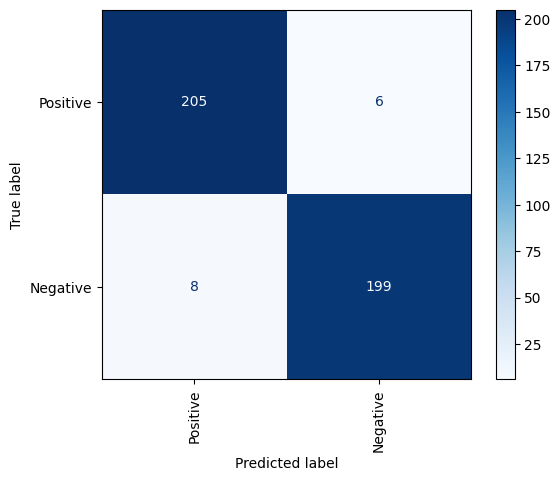

The accuracy of the final model is: 0.9665071770334929


In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

cmd = ConfusionMatrixDisplay

cmd.from_estimator(
    final_model,
    X_test_vectorized,
    y_test,
    display_labels=['Positive', 'Negative'],
    cmap='Blues',
    xticks_rotation='vertical'
)

plt.show()

# Calculate accuracy
print(
    'The accuracy of the final model is: ' +
    str(
        accuracy_score(
            y_test,
            final_model.predict(X_test_vectorized)
        )
    )
)

In [26]:
# Here you change the reviews
text = 'Adayala road is clear'

# Make a prediction for this review
score = final_model.predict_proba(
    vectorizer.transform([text])
)[0][1]

if score > 0.5:
    attitude = 'negative'
else:
    attitude = 'positive'

print(
    'The prediction result of this review is: ' +
    attitude
)

The prediction result of this review is: positive
